<a href="https://colab.research.google.com/github/natalialekszycka/projekt-programowanie/blob/main/drug_consumption_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drug Consumption – Klasyfikacja uzytkownikow LSD

Cel: przewidywanie czy osoba uzywala LSD na podstawie cech demograficznych i osobowosci.
Dane: UCI Drug Consumption Dataset – 1885 respondentow, 11 cech.

In [24]:
!pip install ucimlrepo -q

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

## 1. Wczytanie danych

In [26]:
drug_data = fetch_ucirepo(id=373)
X_raw = drug_data.data.features
y_raw = drug_data.data.targets
df = pd.concat([X_raw, y_raw], axis=1)
print("Ksztalt danych:", df.shape)
df.head()

Ksztalt danych: (1885, 31)


,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,...,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1885 non-null   float64
 1   gender     1885 non-null   float64
 2   education  1885 non-null   float64
 3   country    1885 non-null   float64
 4   ethnicity  1885 non-null   float64
 5   nscore     1885 non-null   float64
 6   escore     1885 non-null   float64
 7   oscore     1885 non-null   float64
 8   ascore     1885 non-null   float64
 9   cscore     1885 non-null   float64
 10  impuslive  1885 non-null   float64
 11  ss         1885 non-null   float64
 12  alcohol    1885 non-null   object 
 13  amphet     1885 non-null   object 
 14  amyl       1885 non-null   object 
 15  benzos     1885 non-null   object 
 16  caff       1885 non-null   object 
 17  cannabis   1885 non-null   object 
 18  choc       1885 non-null   object 
 19  coke       1885 non-null   object 
 20  crack   

In [28]:
df.describe()

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,impuslive,ss
count,1885.00000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000
mean,0.03461,-0.000256,-0.003806,0.355542,-0.309577,0.000047,-0.000163,-0.000534,-0.000245,-0.000386,0.007216,-0.003292
std,0.87836,0.482588,0.950078,0.700335,0.166226,0.998106,0.997448,0.996229,0.997440,0.997523,0.954435,0.963701
min,-0.95197,-0.482460,-2.435910,-0.570090,-1.107020,-3.464360,-3.273930,-3.273930,-3.464360,-3.464360,-2.555240,-2.078480
25%,-0.95197,-0.482460,-0.611130,-0.570090,-0.316850,-0.678250,-0.695090,-0.717270,-0.606330,-0.652530,-0.711260,-0.525930
50%,-0.07854,-0.482460,-0.059210,0.960820,-0.316850,0.042570,0.003320,-0.019280,-0.017290,-0.006650,-0.217120,0.079870
75%,0.49788,0.482460,0.454680,0.960820,-0.316850,0.629670,0.637790,0.723300,0.760960,0.584890,0.529750,0.765400
max,2.59171,0.482460,1.984370,0.960820,1.907250,3.273930,3.273930,2.901610,3.464360,3.464360,2.901610,1.921730


## 2. Wizualizacja danych

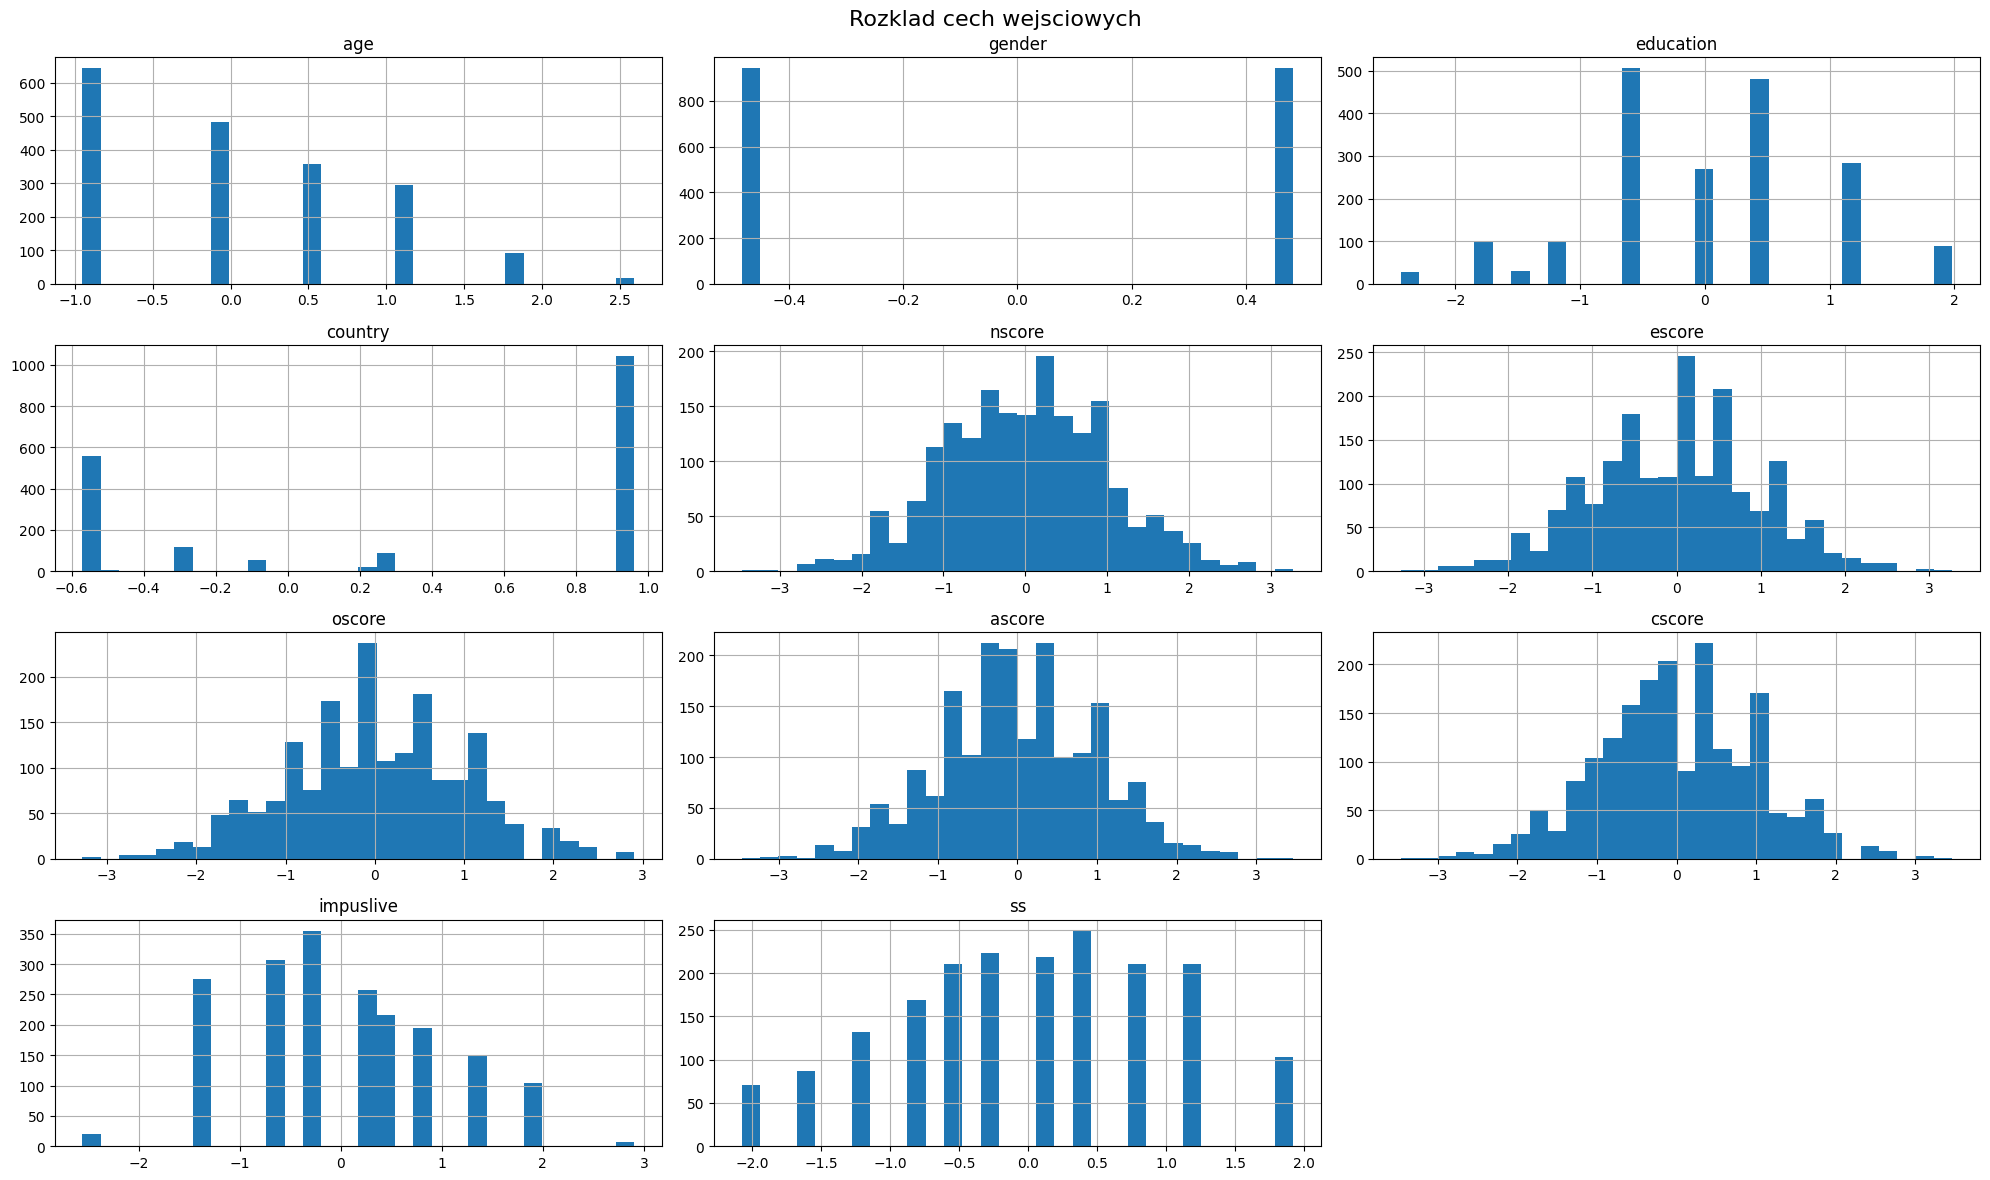

In [29]:
feature_cols = ["age", "gender", "education", "country",
                "nscore", "escore", "oscore", "ascore", "cscore",
                "impuslive", "ss"]

df[feature_cols].hist(bins=30, figsize=(20, 12))
plt.suptitle("Rozklad cech wejsciowych", fontsize=16)
plt.tight_layout()
plt.show()

## 3. Analiza korelacji

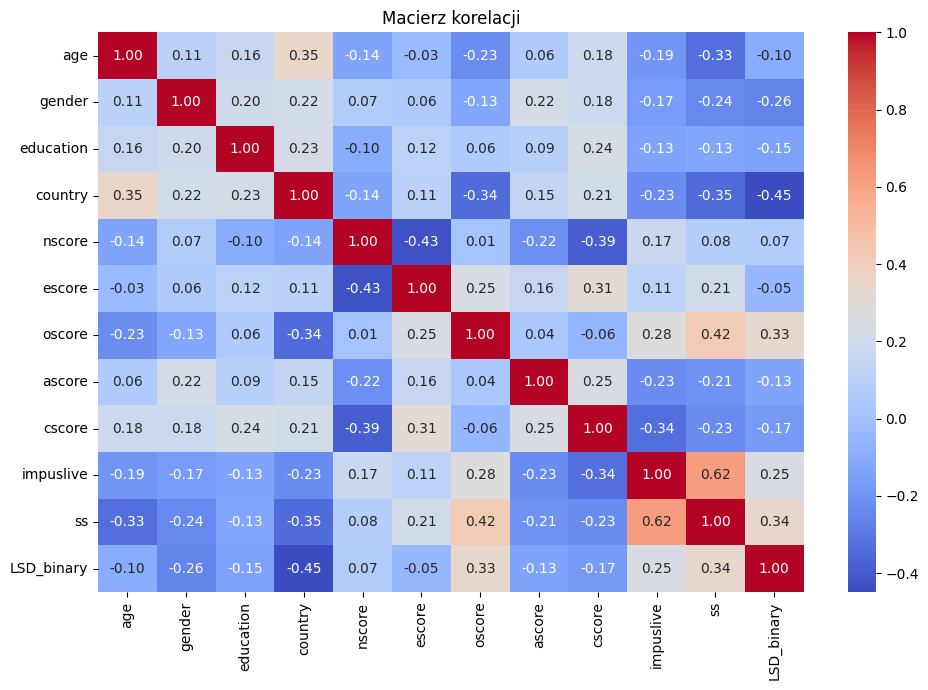

In [30]:
# Tworzymy binarna zmienna docelowa: 0 = nigdy nie uzywal LSD, 1 = uzywal
df["LSD_binary"] = (df["lsd"] != "CL0").astype(int)

plt.figure(figsize=(10, 7))
corr = df[feature_cols + ["LSD_binary"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Macierz korelacji")
plt.tight_layout()
plt.show()

## 4. Czyszczenie danych

Semeron to fikcyjny narkotyk w ankiecie – usuwamy osoby ktore zadeklarowaly jego uzycie (nierzetelne odpowiedzi).

In [31]:
print("Braki danych:")
print(df[feature_cols].isnull().sum())

before = len(df)
df = df[df["semer"] == "CL0"].copy()
print(f"\nUsunięto {before - len(df)} wierszy. Pozostało: {len(df)}")

Braki danych:
age          0
gender       0
education    0
country      0
nscore       0
escore       0
oscore       0
ascore       0
cscore       0
impuslive    0
ss           0
dtype: int64

Usunięto 8 wierszy. Pozostało: 1877


## 5. Przygotowanie danych

In [32]:
X = df[feature_cols]
y = df["LSD_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Trening: {X_train.shape[0]} probek, Test: {X_test.shape[0]} probek")

Trening: 1501 probek, Test: 376 probek


## 6. Model 1 – Regresja Logistyczna

In [33]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
pred_log = log_model.predict(X_test_scaled)

print(classification_report(y_test, pred_log, target_names=["Nie uzywal", "Uzywal"]))

              precision    recall  f1-score   support

  Nie uzywal       0.75      0.78      0.76       214
      Uzywal       0.69      0.66      0.68       162

    accuracy                           0.73       376
   macro avg       0.72      0.72      0.72       376
weighted avg       0.72      0.73      0.73       376



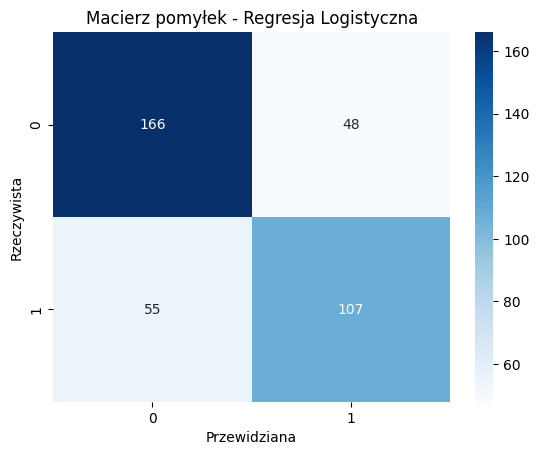

In [34]:
sns.heatmap(confusion_matrix(y_test, pred_log), annot=True, fmt="d", cmap="Blues")
plt.title("Macierz pomyłek - Regresja Logistyczna")
plt.xlabel("Przewidziana")
plt.ylabel("Rzeczywista")
plt.show()

## 7. Model 2 – Random Forest z GridSearchCV

In [35]:
params = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params, cv=3, scoring="f1", n_jobs=-1
)
grid.fit(X_train, y_train)
print("Najlepsze parametry:", grid.best_params_)

Najlepsze parametry: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [36]:
pred_rf = grid.best_estimator_.predict(X_test)
print(classification_report(y_test, pred_rf, target_names=["Nie uzywal", "Uzywal"]))

              precision    recall  f1-score   support

  Nie uzywal       0.77      0.75      0.76       214
      Uzywal       0.68      0.70      0.69       162

    accuracy                           0.73       376
   macro avg       0.72      0.72      0.72       376
weighted avg       0.73      0.73      0.73       376



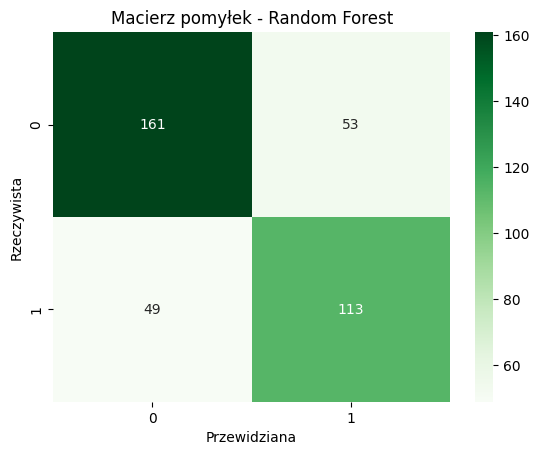

In [37]:
sns.heatmap(confusion_matrix(y_test, pred_rf), annot=True, fmt="d", cmap="Greens")
plt.title("Macierz pomyłek - Random Forest")
plt.xlabel("Przewidziana")
plt.ylabel("Rzeczywista")
plt.show()

# 8. Ważność cech



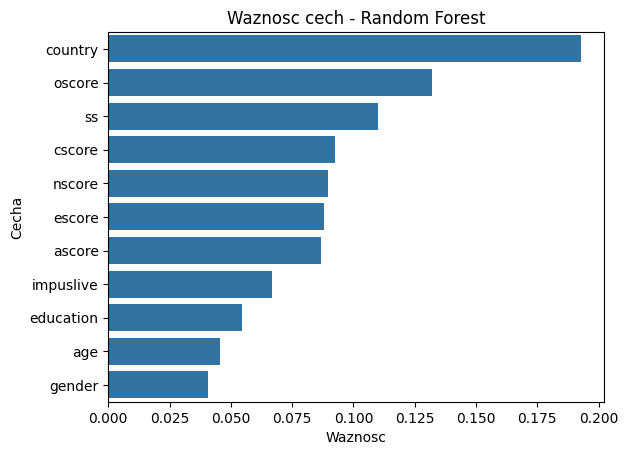

In [38]:
importance = pd.DataFrame({
    "Cecha": feature_cols,
    "Waznosc": grid.best_estimator_.feature_importances_
}).sort_values("Waznosc", ascending=False)

sns.barplot(data=importance, x="Waznosc", y="Cecha")
plt.title("Waznosc cech - Random Forest")
plt.show()

## 9. Porownanie modeli i wnioski

               Model  Accuracy  F1-score
Regresja Logistyczna  0.726064  0.675079
       Random Forest  0.728723  0.689024


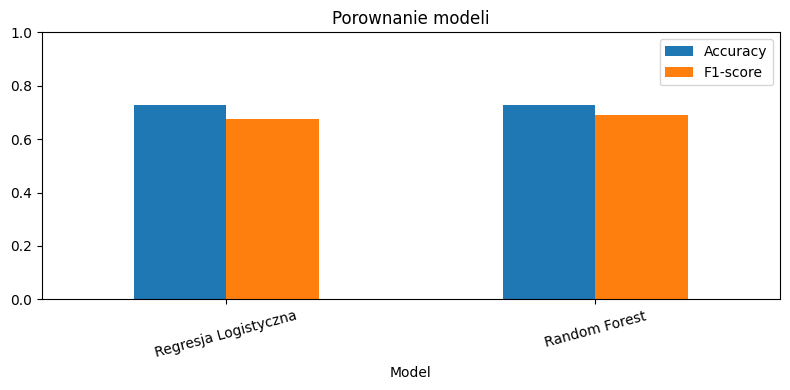

In [39]:
from sklearn.metrics import f1_score, accuracy_score

wyniki = pd.DataFrame({
    "Model": ["Regresja Logistyczna", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, pred_log), accuracy_score(y_test, pred_rf)],
    "F1-score": [f1_score(y_test, pred_log), f1_score(y_test, pred_rf)]
})
print(wyniki.to_string(index=False))

wyniki.plot(x="Model", kind="bar", figsize=(8, 4))
plt.title("Porownanie modeli")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Wnioski

- **Random Forest osiagnal lepsze wyniki niz Regresja Logistyczna** (wyzsze F1-score i Accuracy).
- Najwazniejsze cechy to **Openness to experience (Oscore)** i **Sensation Seeking (SS)**.
- Dane nie mialy brakow. Usunieto 8 nierzetelnych obserwacji (Semeron).
